# Training an Image Classifier using TensorFlow

# 1. Overview

As the name suggests, image classification is the process in which images are classified into their respective classes. It is one of the most fundamental concepts as far as Deep Learning in Computer Vision is concerned. In the past, classical techniques such as clustering were used to perform classification.

But, with the introduction of Deep Learning techniques, CNNs have proven to be great for classifying images with great accuracy. Hence, it is important to understand the entire pipeline for training an image classifier.  

In this notebook, we will use the **TensorFlow** framework to train a VGG16-based classifier to classify leaf diseases using the **Citrus Leaves** dataset.

# 2. Installation

# 2.1 TensorFlow Datasets

If you are running this notebook directly on Google Colab, then you need not run the next code snippet for installing **TensorFlow Datasets**. However, if you using a local environment (or) Kaggle, then you might have to install this dependency.

In [1]:
!pip install tensorflow-datasets

# 2.2 Import Packages

In this section, it can be observed that the necessary packages such as **TensorFlow**, **TensorFlow Datasets**, and **MatplotLib** have been imported.

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam, SGD

# 3. Prepare Citrus Leaves Dataset

<img src="https://www.dropbox.com/scl/fi/xjslttkr65q84k4q3nvjc/citrus_leaves-0.1.2.png?rlkey=35wlwnz9pdar05hjguhkw3ouo&st=t1tpnkya&dl=1" width="500" height="500">

**CITATION:** Rauf, H. T., Saleem, B. A., Lali, M. I. U., Khan, M. A., Sharif, M., & Bukhari, S. A. C. (2019). A citrus fruits and leaves dataset for detection and classification of citrus diseases through machine learning. Data in Brief, 26, 104340. Elsevier.

As mentioned earlier in the initial **Overview** section, we will be using the **Citrus Leaves** dataset to perform disease classification on images of leaves. In the below code snippet, a specific method has been utilized to load the **Citrus Leaves** dataset from **TensorFlow Datasets**.

```
tfds.load(name_of_dataset)
```



Of course, this dataset cannot be used directly. Hence, we need to perform some kind of splitting for training and validation. As a general rule of thumb, we follow a 80:20 split for preprocessing the dataset.

In [3]:
# Load the citrus_leaves dataset
dataset_train, info_train = tfds.load(
    'citrus_leaves',
    with_info=True,
    as_supervised=True,
    split='train[:80%]',
    shuffle_files=True
)
dataset_valid, info_valid = tfds.load(
    'citrus_leaves',
    with_info=True,
    as_supervised=True,
    split='train[80%:]',
    shuffle_files=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/citrus_leaves/incomplete.0SN87N_0.1.2/citrus_leaves-train.tfrecord*...:   …

Dataset citrus_leaves downloaded and prepared to /root/tensorflow_datasets/citrus_leaves/0.1.2. Subsequent calls will reuse this data.


I0000 00:00:1763255837.531915      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763255837.532514      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


From the output shown above, we can confirm that this method was able to download and load the **Citrus Leaves** dataset into our environment. It also split the dataset for training and validation. To validate the split, let's print out the length for the **train** and **valid** datasets.


In [4]:
print(len(dataset_train))
print(len(dataset_valid))

475
119


It shows that the **train** dataset has 475 images, and the **valid** dataset has 119 images. While we are at it, let's also check the labels / classes that are associated with this dataset.

In [5]:
label_info = info_train.features['label']
print(label_info.names)

['Black spot', 'canker', 'greening', 'healthy']


Great, looks like there are 4 main classes in this dataset - **Black spot**, **canker**, **greening**, and **healthy**.

While preparing datasets for training image classifiers, it is also crucial to do some kind of visual inspection to get an idea of how the images look in reality. For this, we will first loop through the entire **train** dataset and print out the shape of the tensors using this construct:

```
{'image' : tf.tensor, 'label' : tf.Tensor}
```

In [6]:
for example in dataset_train:  # example is `{'image': tf.Tensor, 'label': tf.Tensor}`
    image = example[0]
    label = example[1]
    print(image.shape, label)
    break

(256, 256, 3) tf.Tensor(1, shape=(), dtype=int64)


The output clearly shows that the images that we loaded into the **train** and **valid** datasets, have been converted into **Tensors** of shape **(256, 256, 3)**. In this case, the size of each image is **256x256** and it has **3-channels**. Alright, now let's have a visual look at the images themselves.

,image,label
0,,1 (canker)
1,,3 (healthy)
2,,2 (greening)
3,,2 (greening)
4,,1 (canker)
5,,2 (greening)
6,,1 (canker)
7,,0 (Black spot)

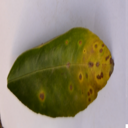
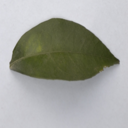
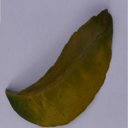
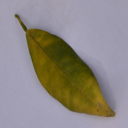
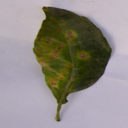
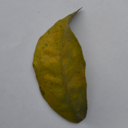
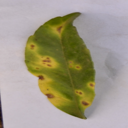
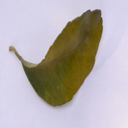

In [7]:
tfds.as_dataframe(dataset_train.take(8), info_train)

# 4. Preprocess Dataset

# 4.1 Image Resizing

We cannot use the dataset as it is, without some preprocessing steps. This can often include augmentation techniqes such as **resizing**, **rotation**, **brightness / contrast variations**, **sharpness / blurring**, etc. But, for this sake of this notebook, we will be only resizing the input image size from **256** to **224**.

In [8]:
# Preprocess the data
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label

This function `preprocess` takes the `image` and `label` as input parameters, reshapes them to **224** size and returns them. From here, both the `train` and `valid` datasets can be passed through this function to perform the resizing operation. It can also be observed that the `dataset.map()` method has been used to initialize the `batch_size` as 32 for both the datasets.

In [9]:
train_ds = dataset_train.map(preprocess).shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = dataset_valid.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# 5. Image Classifier - VGG16 Model

# 5.1 Base Architecture

In the figure shown below, VGG16 model's architecture has been shown. It is made up of a combination of Convolution and Pooling blocks. This forms the structure of this classification model as well.

<img src="https://www.dropbox.com/scl/fi/3wak038c5s3gnnnn06wis/vgg16.drawio.png?rlkey=89m5nkz2n6t3idvn68frdxghm&st=6a3zxtj1&dl=1">

In the below code snippet, the `base_model` has been initialized with an input image size of `224x224`.



In [10]:
# Load the VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 5.2 Model Architecture Modification

<img src="https://www.dropbox.com/scl/fi/tgwpxn1wlq7hg4wwmie4r/mod-fin-vgg16.drawio.png?rlkey=1zlwzk0gtauaic4hysnue005q&st=qfi50k9v&dl=1">

As part of modification, let's tweak the `base_model` and add the following components:


1.   Flatten the existing output of the `base_model`.
2.   Add a new `Dense` layer with `relu` activation function, after flattening.
3.   Introduce a `Dropout` of `0.5` after the dense layer.
4.   Add a final `predictions` layer which has the same number of nodes as `num_classes`, and `softmax` activation function for final classification.


The below code snippet does exactly the same, in TensorFlow.

In [11]:
# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(info_train.features['label'].num_classes, activation='softmax')(x)

# 5.3 Model Creation and Compilation

In this sub-section, an instance of the modified model has been created using the `Model()` method and compiled using the `sparse_categorical_crossentropy` loss function with an initial `learning_rate` of `0.0001`.

In [12]:
# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

In [13]:
# Compile the model
model.compile(optimizer=SGD(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5.4 Model Training

Alright, now it's time to train this newly modified model. In TensorFlow, you can use the `model.fit()` method for this. Note that the initial value for number of `epochs` has been set to **20**, the train dataset (`train_ds`) and valid dataset (`valid_ds`) have also been given as an input.  

In [14]:
# Train the model
history = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20


I0000 00:00:1763256727.851063     142 service.cc:148] XLA service 0x790aa000cfd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763256727.851839     142 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763256727.851858     142 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763256728.164523     142 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763256772.260869     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.3765 - loss: 6.0082 - val_accuracy: 0.5294 - val_loss: 1.4174
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 581ms/step - accuracy: 0.5009 - loss: 1.9176 - val_accuracy: 0.5882 - val_loss: 1.0332
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 572ms/step - accuracy: 0.5918 - loss: 1.1549 - val_accuracy: 0.6807 - val_loss: 0.8342
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 570ms/step - accuracy: 0.6797 - loss: 0.8845 - val_accuracy: 0.7227 - val_loss: 0.7252
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 573ms/step - accuracy: 0.7675 - loss: 0.6328 - val_accuracy: 0.7311 - val_loss: 0.6595
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 580ms/step - accuracy: 0.7830 - loss: 0.6176 - val_accuracy: 0.7311 - val_loss: 0.6454
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 590ms/step - accuracy: 0.8126 - loss: 0.4637 - val_accuracy: 0.7563 - val_loss: 0.6106
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 598ms/step - accuracy: 0.8146 - loss: 0.5313 - val_accuracy: 0.8067 - val_l

# 6. Performance Evaluation

In this final section, the trained model has been evaluated based on two criteria:

1.   Training and Validation Loss
2.   Training and Validation Accuracy

In [15]:
# Evaluate the model
loss, accuracy = model.evaluate(test_ds)
print(f'Test accuracy: {accuracy:.2f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.8710 - loss: 0.3752
Test accuracy: 0.86


The graphical representation for both of the above mentioned components have also been given below.

Text(0.5, 1.0, 'Loss Curves')

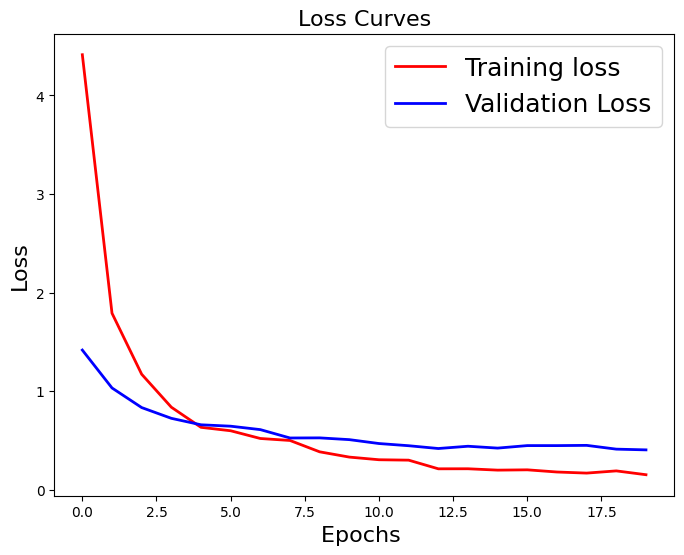

In [16]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'b',linewidth=2.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

Text(0.5, 1.0, 'Accuracy Curves')

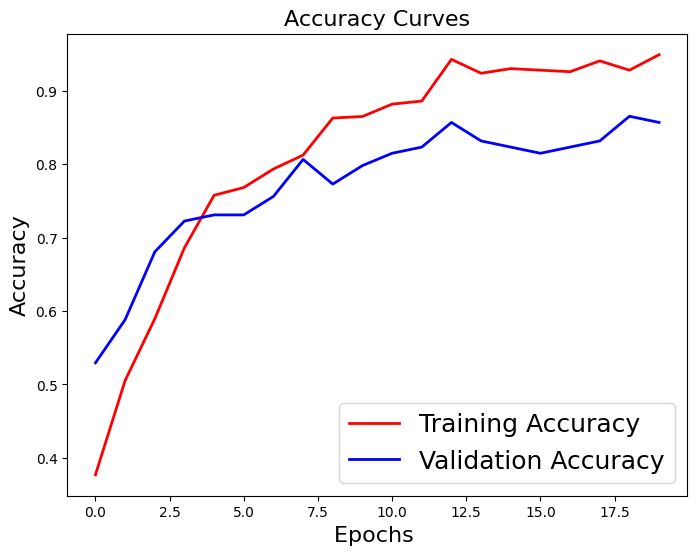

In [17]:
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=2.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=2.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

# 7. Conclusion

In this notebook, we've explored the entire pipeline for training an Image Classifier using TensorFlow framework. We used `Citrus Leaves` from TensorFlow Datasets, and utilized a modified version of VGG16 model for training. In the end, we also looked at the evaluation metrics.